# Analysis without the portal

The Data Portal is one front end for the analysis core, not the only one. Everything it does
(preview a shot, run a recipe over a scan) is a few Python calls you can make from a notebook,
which is the quickest way to try a variant of a recipe or to do a one-off analysis.

This notebook uses a real HTU scan: **26_0929 Scan023**, an EMQ1 current scan imaged on the
A-line electron-beam camera `UC_ALineEBeam3`, and that camera's recipe from the configs repository.

**You need:** the data share mounted, `~/.config/geecs_python_api/config.ini` pointing at it and at
the configs repository, and an environment with ScanAnalysis installed (the Data Portal's env with
its `analysis` extra works). Reading the HDF5 frame stacks the cameras now write needs
h5py 3.16 or newer (HDF5 2.0); an older h5py maps no frames.

**Sections 1–3 write nothing to disk.** Only section 4, the full scan run, writes outputs, exactly
as the portal's Run button does.

See the [recipe reference](https://geecs-plugins.readthedocs.io/en/latest/sites/analysis_recipes/index.html) for what each step, measure and scalar means.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd

from geecs_data_utils import ScanData
from image_analysis.config import load_diagnostic

scan = ScanData.from_date(year=2026, month=9, day=29, number=23, experiment="Undulator")
rows = scan.data_frame  # the scan's s-file: one row per shot
recipe = load_diagnostic("UC_ALineEBeam3")  # by file stem, from the configs repository

print(type(recipe).__name__, "for", recipe.device)
print("steps:  ", [step.model_dump() for step in recipe.steps])
print("measure:", recipe.measure.model_dump())

AnalysisRecipe for UC_ALineEBeam3
steps:   [{'step': 'background_constant', 'level': 50}, {'step': 'roi', 'bounds': [[1, 964], [1, 1289]]}, {'step': 'zero_below', 'level': 0}]
measure: {'kind': 'beam'}


This camera now saves one HDF5 stack per scan instead of a file per shot. A recipe reads the stack
only when its input says `format: device_hdf5`; this recipe predates that, so set it here. (The
same line belongs in the recipe file, or the portal's Run will find no files.)

In [2]:
recipe = recipe.model_copy(
    update={"input": recipe.input.model_copy(update={"format": "device_hdf5"})}
)

## 1. One shot, as the portal preview computes it

`prepare_source` maps shot numbers to frames (here, frames inside the stack), `compile_recipe`
checks the recipe against the analysis core, and `analyze_v2` runs the steps and the measure on
one raw frame. `render.single` draws it with the recipe's own `figure` settings.

shot 1: {'image_total': 40574414.0, 'image_peak_value': 4045.0, 'x_CoM': 402.5, 'x_rms': 287.69, 'x_fwhm': 4.96, 'x_peak_location': 1.0, 'y_CoM': 476.65, 'y_rms': 243.79, 'y_fwhm': 213.66, 'y_peak_location': 400.0}


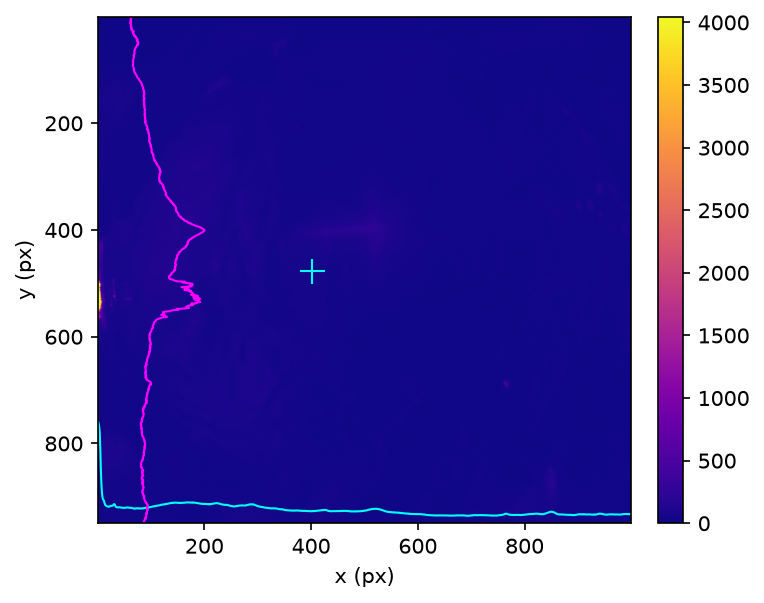

In [3]:
from geecs_analysis.compat.v2 import analyze_v2
from geecs_analysis.recipe import compile_recipe, figure_of
from geecs_analysis.render import single
from scan_analysis.core_source import prepare_source

source = prepare_source(recipe, scan.paths.get_folder(), rows)
compiled = compile_recipe(recipe)
first = min(source.references)

with source:
    result = analyze_v2(source.load(first), compiled)

print(
    f"shot {first}:",
    {
        k: round(v, 2)
        for k, v in result.scalars.items()
        if not k.startswith(("x_45", "y_45"))
    },
)
display(single(result, figure_of(recipe)))

## 2. Every shot, in memory

The same call in a loop gives a table you can group and plot however you like. Nothing is
written: the scalars live in a DataFrame, joined to the s-file on `Shotnumber`.

In [4]:
CURRENT = "U_EMQTripletBipolar Current_Limit.Ch1"


def measure_scan(recipe):
    """Measure every shot of the scan with a recipe; one row per shot."""
    compiled = compile_recipe(recipe)
    source = prepare_source(recipe, scan.paths.get_folder(), rows)
    with source:  # keeps the stack open for the whole loop
        out = [
            {"Shotnumber": shot, **analyze_v2(source.load(shot), compiled).scalars}
            for shot in sorted(source.references)
        ]
    return pd.DataFrame(out).merge(
        rows[["Shotnumber", "Bin #", CURRENT]], on="Shotnumber"
    )


shots = measure_scan(recipe)
per_bin = shots.groupby("Bin #")[
    [CURRENT, "x_fwhm", "y_fwhm", "image_peak_value"]
].mean()
per_bin.round(2)

,U_EMQTripletBipolar Current_Limit.Ch1,x_fwhm,y_fwhm,image_peak_value
Bin #,,,,
1,1.00,5.03,223.76,4045.0
2,1.09,5.06,212.80,4045.0
3,1.17,5.07,195.98,4045.0
4,1.26,4.96,159.35,4045.0
5,1.34,5.44,102.52,4045.0
6,1.43,5.37,50.56,4045.0
7,1.51,5.29,33.94,4045.0
8,1.60,5.20,59.40,4045.0
9,1.69,5.20,148.54,4045.0


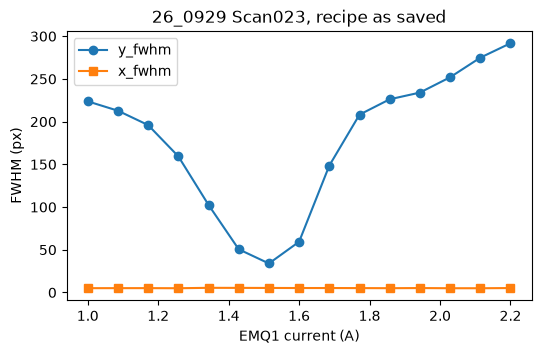

In [5]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(per_bin[CURRENT], per_bin["y_fwhm"], "o-", label="y_fwhm")
ax.plot(per_bin[CURRENT], per_bin["x_fwhm"], "s-", label="x_fwhm")
ax.set(
    xlabel="EMQ1 current (A)",
    ylabel="FWHM (px)",
    title="26_0929 Scan023, recipe as saved",
)
ax.legend();

`y_fwhm` shows the focus clearly. `x_fwhm` sits near 5 px at every current, `x_peak_location`
is 1, and `image_peak_value` is 4045 (saturated) on every shot. Something saturated at the
camera's left edge (columns 0 to 7, around rows 496 to 549, visible in the image above) makes
the x projection peak at the edge, so its half-maximum width describes that feature, not the
beam. The recipe's ROI (`[[1, 964], [1, 1289]]`) is larger than this 950×1000 frame, so it
crops nothing.

## 3. Try a variant of the recipe

A recipe is a Pydantic model, so a variant is one `model_validate` away. Two changes: an ROI that
starts at column 20, past the edge feature, and a background level of 100 counts instead of 50
(the pedestal's median is about 82 counts, so 50 leaves most of it in).

,U_EMQTripletBipolar Current_Limit.Ch1,x_fwhm,y_fwhm,image_peak_value
Bin #,,,,
1,1.00,496.14,81.89,1590.60
2,1.09,494.26,67.12,1695.50
3,1.17,473.14,82.65,1647.15
4,1.26,497.93,43.77,1613.70
5,1.34,496.60,35.42,2326.40
6,1.43,462.46,27.56,2204.45
7,1.51,372.77,23.80,3981.00
8,1.60,174.18,27.19,2426.00
9,1.69,180.32,42.80,1943.80


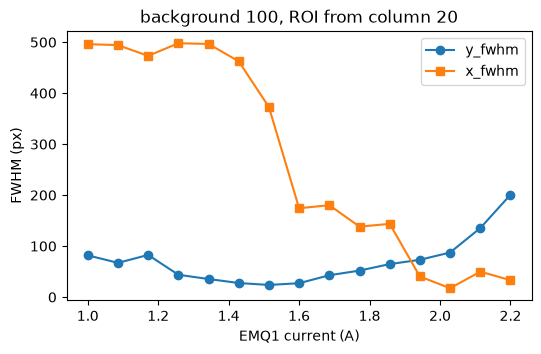

In [6]:
from geecs_schemas.analysis import AnalysisRecipe

steps = [step.model_dump() for step in recipe.steps]
background = {"step": "background_constant", "level": 100}
roi = {
    "step": "roi",
    "bounds": [[0, 950], [20, 1000]],
    "units": "index",
}  # (y, x), half-open
variant = AnalysisRecipe.model_validate(
    {**recipe.model_dump(), "steps": [background, roi, *steps[2:]]}
)
per_bin_v = (
    measure_scan(variant)
    .groupby("Bin #")[[CURRENT, "x_fwhm", "y_fwhm", "image_peak_value"]]
    .mean()
)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(per_bin_v[CURRENT], per_bin_v["y_fwhm"], "o-", label="y_fwhm")
ax.plot(per_bin_v[CURRENT], per_bin_v["x_fwhm"], "s-", label="x_fwhm")
ax.set(
    xlabel="EMQ1 current (A)",
    ylabel="FWHM (px)",
    title="background 100, ROI from column 20",
)
ax.legend()
per_bin_v.round(2)

The y focus is now sharp (about 24 px at 1.51 A) and the saturated edge no longer sets
`image_peak_value`. `x_fwhm` now trends down as the current rises, but treat it with care: at low
current it sits near the width of the frame and it jumps by hundreds of pixels between neighbouring
currents. There the beam is broad and faint in x and sits on a structured background, so the
half maximum is set by the background, and a constant level can't fix that. The proper fix is a `background_frame` step bound to a recorded
background, and there is one from the same day: Scan022, "bkg on aline3". See the
[`background_frame`](https://geecs-plugins.readthedocs.io/en/latest/sites/analysis_recipes/index.html#step-background_frame) card.

If a variant is better, make it the recipe: add the step in the portal's config editor (it
previews on a real shot before you save), or edit the YAML in the configs repository.

## 4. The full scan run (writes files)

This is what the portal's **Run** button calls. It writes summary figures under the day's
`analysis/ScanNNN/` folder and adds the scalars to the analysis s-file as columns prefixed with the
recipe's `output_name` (the device name unless set). It never creates or modifies the scan folder
itself. It is not executed here.

In [7]:
from scan_analysis.config import create_scan_analyzer

analyzer = create_scan_analyzer(recipe)
# display_files = analyzer.run_analysis(scan.paths.get_tag())  # uncomment to write outputs

After a run, `ScanData.from_date(...)` loads the analysis s-file, so the new columns
(`UC_ALineEBeam3_x_fwhm`, ...) sit next to every device's scalars for the same shots.

To run several recipes at once, a group document lists them; see the
[analysis tutorial](https://geecs-plugins.readthedocs.io/en/latest/tutorials/analysis/).